# **Brain Tumor Classification**

## **Dataset**
Source: Kaggle - https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri

Remote Source of dataset: https://github.com/sartajbhuvaji/brain-tumor-classification-dataset

_________________________________________
Description:

The dataset contains 3264 brain MRI data. The images are already split into Training(2870 images) and Testing(394 images) folders.
Each folder has more four subfolders. These folders have MRIs of respective tumor classes.

Classes:

1.   glioma_tumor (826 training + 100 testing)
2.   meningioma_tumor (822 training + 115 testing)

1.   no_tumor (395 training + 105 testing)
2.   pituitary_tumor (827 training + 74 testing)





## **Code**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, Conv2D, MaxPool2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import datetime, os
from tqdm import tqdm
import cv2
from sklearn.utils import shuffle

In [ ]:
!unzip -u "/content/drive/MyDrive/BhuvannCLG/BTSCNF.zip" -d "/content/drive/MyDrive/BhuvannCLG/BTSCNF"

Archive:  /content/drive/MyDrive/BhuvannCLG/BTSCNF.zip


In [ ]:
labels = ['glioma_tumor','meningioma_tumor','no_tumor','pituitary_tumor']

In [ ]:
x_train=[]
y_train=[]
x_test=[]
y_test=[]
img_size=150
for i in labels:
  folder_path=os.path.join('/content/drive/MyDrive/BhuvannCLG/BTSCNF/Training_N&F/',i)
  for j in tqdm(os.listdir(folder_path)):
    img = cv2.imread(os.path.join(folder_path,j))
    img = cv2.resize(img,(img_size,img_size))
    x_train.append(img)
    y_train.append(i)

for i in labels:
  folder_path = os.path.join('/content/drive/MyDrive/BhuvannCLG/BTSCNF/Testing_N&F',i)
  for j in tqdm(os.listdir(folder_path)):
    img = cv2.imread(os.path.join(folder_path,j))
    img = cv2.resize(img,(img_size,img_size))
    x_test.append(img)
    y_test.append(i)


100%|██████████| 518/518 [00:05<00:00, 99.86it/s] 


In [ ]:
type(x_train)
type(x_test)
type(y_train)
type(y_test)

list

In [ ]:
#converting list into array
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(20590, 150, 150, 3)
(2258, 150, 150, 3)
(20590,)
(2258,)


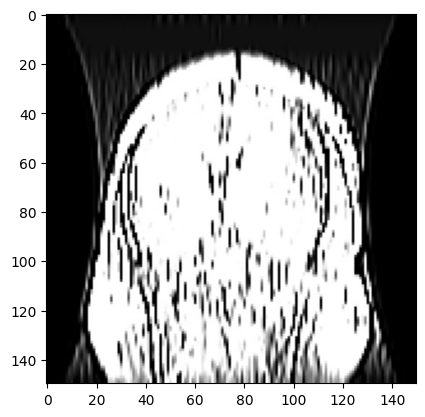

In [ ]:
#display of sample image
plt.imshow(x_train[764])

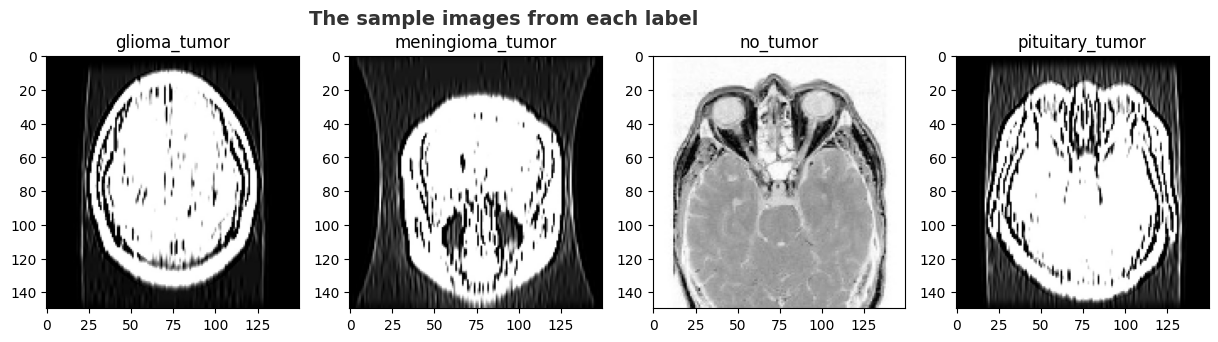

In [ ]:
#Displaying sample images from each class
k=0
fig, ax = plt.subplots(1,4, figsize=(15,15))
fig.text(s='The sample images from each label', size=14, fontweight='bold',y=0.60,x=0.30,alpha=0.8)
for i in labels:
  j=0
  while True:
    if y_train[j]==i:
      ax[k].imshow(x_train[j])
      ax[k].set_title(y_train[j])
      ax[k].axis('on')
      k+=1
      break
    j+=1

In [ ]:
x_train, y_train = shuffle(x_train, y_train, random_state=130)

In [ ]:
x_train.shape

(20590, 150, 150, 3)

One hot encoding



In [ ]:
y_train

array(['meningioma_tumor', 'no_tumor', 'pituitary_tumor', ...,
       'meningioma_tumor', 'meningioma_tumor', 'meningioma_tumor'],
      dtype='<U16')

In [ ]:
y_train_onehot = []
for i in y_train:
  y_train_onehot.append(labels.index(i))
y_train = tf.keras.utils.to_categorical(y_train_onehot)

y_test_onehot = []
for i in y_test:
  y_test_onehot.append(labels.index(i))
y_test = tf.keras.utils.to_categorical(y_test_onehot)

CNN

In [ ]:
from keras import regularizers

cnnModel= Sequential()
cnnModel.add(layers.Conv2D(32,(2,2),activation='relu',input_shape=(150,150,3), kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Conv2D(64,(2,2),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.MaxPool2D((2,2)))
cnnModel.add(layers.Dropout(.2))

cnnModel.add(layers.Conv2D(128,(2,2),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Conv2D(128,(2,2),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.MaxPool2D((3,3)))
cnnModel.add(layers.Dropout(.2))

cnnModel.add(layers.Conv2D(128,(3,3),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Conv2D(128,(3,3),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.MaxPool2D((3,3)))
cnnModel.add(layers.Dropout(.3))

cnnModel.add(layers.Conv2D(256,(3,3),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Conv2D(256,(3,3),activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.MaxPool2D((2,2)))
cnnModel.add(layers.Dropout(.3))

cnnModel.add(layers.Flatten())
cnnModel.add(layers.Dense(1024,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Dropout(.4))
cnnModel.add(layers.Dense(512,activation='relu', kernel_regularizer=regularizers.l2(0.001)))
cnnModel.add(layers.Dropout(.4))
cnnModel.add(layers.Dense(4, activation='softmax'))


In [ ]:
cnnModel.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
print(cnnModel.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 149, 149, 32)      416       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 64)      8256      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 64)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 74, 74, 64)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 73, 73, 128)       32896     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 128)       65664     
                                                        

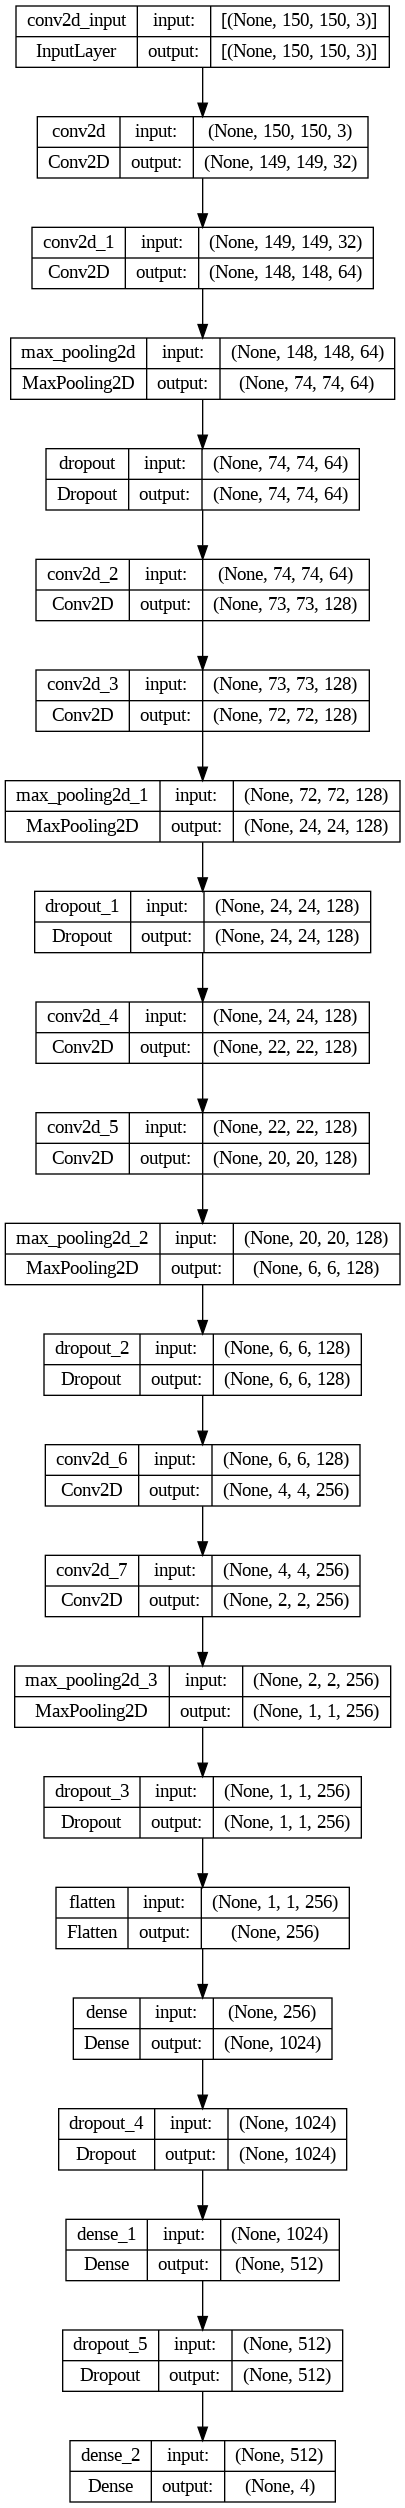

In [ ]:

from keras.utils import plot_model
plot_model(cnnModel, show_shapes=True, show_layer_names=True, rankdir='TB', expand_nested=True)


In [ ]:
#Early stopping method
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
es= tf.keras.callbacks.EarlyStopping(monitor= "val_loss",patience=4)
mc = ModelCheckpoint('/content/drive/MyDrive/BhuvannCLG/BTSCNF/best_cnnmodelf&n.h5', save_best_only=True, save_weights_only=False, monitor='val_accuracy', mode='max')
callbacks=[es,mc]

In [ ]:
cnnHistory=cnnModel.fit(x_train,y_train,validation_split=0.1,batch_size=50, epochs=50,verbose=1,callbacks=[callbacks])

Epoch 1/50
371/371 [==============================] - 75s 168ms/step - loss: 2.8313 - accuracy: 0.2940 - val_loss: 2.3235 - val_accuracy: 0.2997
Epoch 2/50
371/371 [==============================] - 59s 159ms/step - loss: 1.9515 - accuracy: 0.4516 - val_loss: 1.5396 - val_accuracy: 0.6348
Epoch 3/50
371/371 [==============================] - 57s 154ms/step - loss: 1.3690 - accuracy: 0.6491 - val_loss: 1.2659 - val_accuracy: 0.6731
Epoch 4/50
371/371 [==============================] - 57s 153ms/step - loss: 1.0936 - accuracy: 0.7089 - val_loss: 0.9225 - val_accuracy: 0.7712
Epoch 5/50
371/371 [==============================] - 57s 154ms/step - loss: 0.9506 - accuracy: 0.7470 - val_loss: 0.8132 - val_accuracy: 0.7941
Epoch 6/50
371/371 [==============================] - 57s 154ms/step - loss: 0.8429 - accuracy: 0.7723 - val_loss: 0.7388 - val_accuracy: 0.8086
Epoch 7/50
371/371 [==============================] - 57s 154ms/step - loss: 0.7649 - accuracy: 0.7977 - val_loss: 0.7156 - val_ac

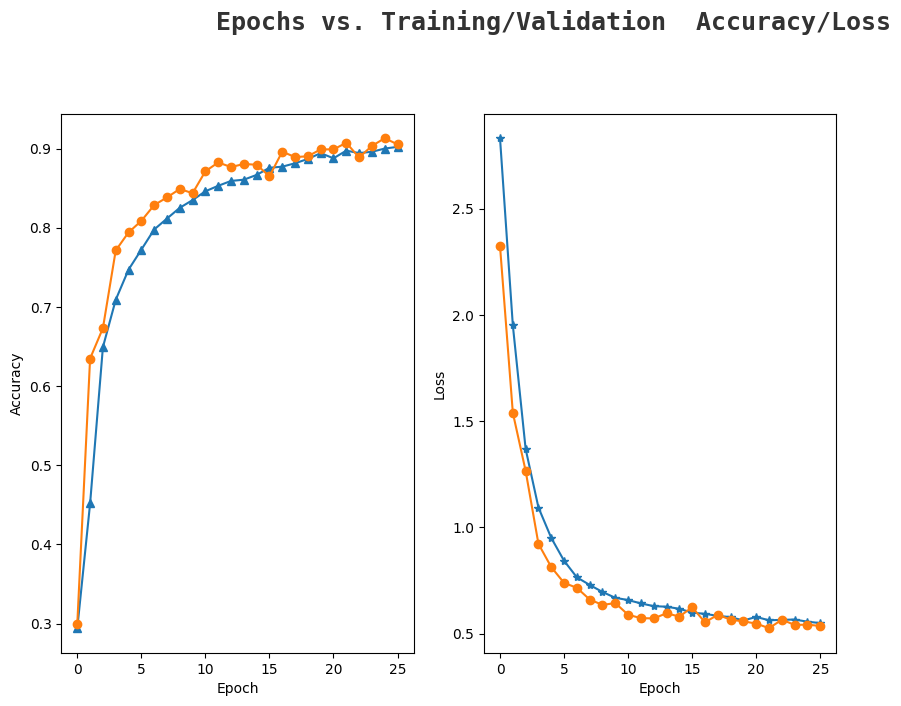

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,7))

fig.text(s='Epochs vs. Training/Validation  Accuracy/Loss',size=18,fontweight='bold',
             fontname='monospace',y=1,x=0.28,alpha=0.8)


ax[0].plot(cnnHistory.history['accuracy'], marker='^')
ax[0].plot(cnnHistory.history['val_accuracy'], marker='o')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')

ax[1].plot(cnnHistory.history['loss'], marker='*', label='loss')
ax[1].plot(cnnHistory.history['val_loss'], marker='o', label='val_loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
plt.show()

CNN - Prediction

In [ ]:
cnnPredictions = cnnModel.predict(x=x_test, verbose=0)
cnnPredictions=np.round(cnnPredictions)

In [ ]:
cnnPredictions

array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], dtype=float32)

CNN - Evaluation

In [ ]:
cnn_y_pred = np.argmax(cnnPredictions, axis=1)
y_test_new = np.argmax(y_test, axis=1)

In [ ]:
cnn_y_pred

array([0, 0, 0, ..., 3, 3, 1])

*   glioma_tumor = 0
*   meningioma_tumor = 1

*   no_tumor = 2
*   pituitary_tumor = 3

In [ ]:
#classification report
cr = classification_report(y_test_new, cnn_y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.51      0.76      0.61       200
           1       0.90      0.66      0.76       805
           2       0.77      0.99      0.87       735
           3       0.92      0.75      0.83       518

    accuracy                           0.80      2258
   macro avg       0.77      0.79      0.77      2258
weighted avg       0.83      0.80      0.80      2258



In [ ]:
#accuracy score
acc=accuracy_score(y_test_new, cnn_y_pred)
print(acc)

0.7971656333038086


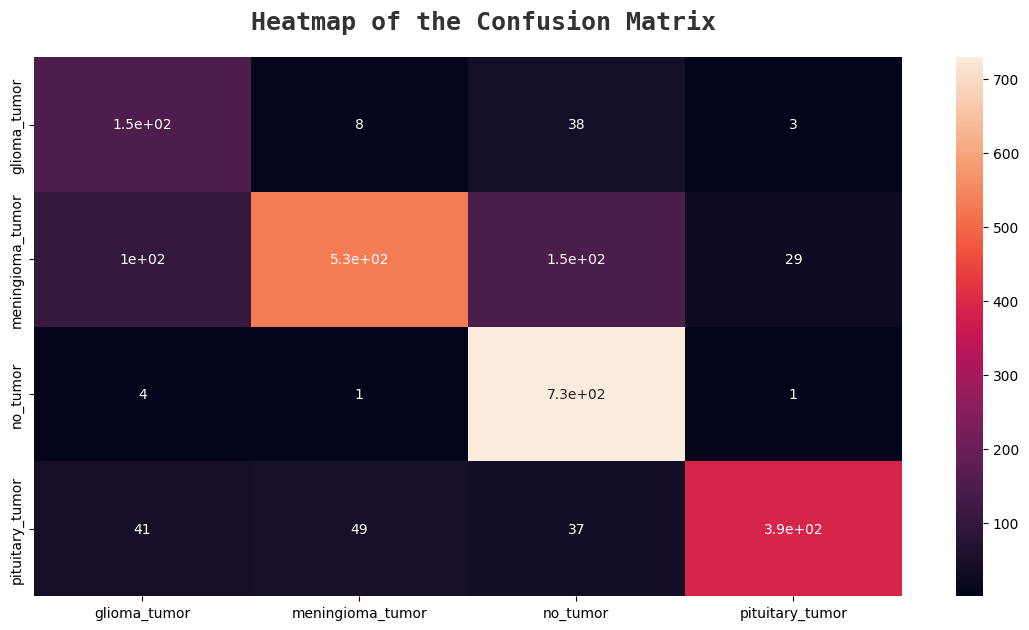

In [ ]:
#confusion matrix
fig,ax=plt.subplots(1,1,figsize=(14,7))
sns.heatmap(confusion_matrix(y_test_new,cnn_y_pred),ax=ax,xticklabels=labels,yticklabels=labels,annot=True)
fig.text(s='Heatmap of the Confusion Matrix',size=18,fontweight='bold',
             fontname='monospace',y=0.92,x=0.28,alpha=0.8)

plt.show()

In [ ]:
#tf.keras.models.save_model(cnnModel,'/content/drive/MyDrive/Dataset/Brain_Tumour/BrainTumour/BraintumourcnnModelF&N.hdf5')

Streamlit deployment

In [ ]:
!pip install -q streamlit

In [ ]:
import PIL

In [ ]:
!pip install streamlit_option_menu

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
from PIL import Image
from streamlit_option_menu import option_menu

st.title('Brain Tumor')
tab1, tab2, tab3, tab4, tab5, tab6, tab7, tab8 = st.tabs(["Overview", "Types", "Symptoms", "Causes", "Risk Factors", "Prevention", "Diagnosis", "Treatment"])


with tab1:
    st.header('Overview')
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/tumor image.png', caption='Brain Tumor')
    st.write('A brain tumour is a growth of brain cells or cells close to the brain. They can happen in or near the brain tissue. Nearby locations include nerves, the pituitary gland, the pineal gland, and the membranes that cover the surface of the brain.')
    st.write('The kind of cells that make up the tumour determine the type of brain tumour. Specialised lab tests, on the tumour cells, can provide information about the cells. This data is used by your medical team to identify the type of brain tumour.')
    st.write("Brain tumours range in size from very small to very large. Some parts of the brain are less active than others. If a brain tumor starts in a part of the brain that's less active, it might not cause symptoms right away. It's size could become quite large before the tumor is detected. Some brain tumours are identified when they are very small because they cause noticable symptoms.")
    st.write("Treatment options depend on the type of brain tumor you have, as well as its size and location. Common treatments include surgery and radiation therapy.")




selected = st.radio("Choose an option:", ("Detection", "Other Options"))

if selected == "Detection":
    @st.cache_data(allow_output_mutation=True)
    def load_BraintumourcnnModel():
       BraintumourcnnModel = tf.keras.models.load_model('/content/drive/MyDrive/BhuvannCLG/BTSCNF/best_cnnmodelf&n.h5')
        return BraintumourcnnModel

    with st.spinner('Model is being loaded...'):
        BraintumourcnnModel = load_BraintumourcnnModel()

    st.write("Brain tumor Classification")
    file = st.file_uploader("Please upload a brain MRI scan file", type=["jpg", "png"])

    import cv2
    from PIL import Image, ImageOps
    import numpy as np
    st.set_option('deprecation.showfileUploaderEncoding', False)

    def import_and_predict(image_data, BraintumourcnnModel):
    size = (150, 150)
    image = ImageOps.fit(image_data, size, Image.ANTIALIAS)
    image = np.asarray(image)
    img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    img_reshape = img[np.newaxis, ...]
    prediction = BraintumourcnnModel.predict(img_reshape)
    return prediction

    if file is None:
        st.text("Please upload an image file")
    else:
        image = Image.open(file)
        st.image(image, use_column_width=True)
        predictions = import_and_predict(image, BraintumourcnnModel)
        score = tf.nn.softmax(predictions[0])
        st.write(predictions)
        st.write(score)
        class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
        st.write(
            "This image most likely belongs to {} with a {:.2f} percent confidence."
            .format(class_names[np.argmax(score)], 100 * np.max(score))
        )
import streamlit as st



with tab2:
    st.header('Types')
    st.write('Primary brain tumours are types of brain tumours that start in the brain. From other body parts, cancer can sometimes reach the brain. These tumours are what are known as metastatic or secondary brain tumours.')
    st.write("Primary brain tumours come in several forms. Non-cancerous brain tumours or benign brain tumours are the terms used to describe brain tumours that are not cancerous. They could enlarge and put pressure on the brain tissue over time. Malignant brain tumours are those that are cancerous brain tumours. They have the potential to spread quickly, invade, and destroy brain tissue.")
    st.write('Benign brain tumours tend to be slow-growing brain tumours, whereas Malignant brain tumours tend to be fast-growing brain tumours.')

    st.subheader('Types of Brain Tumours')

    with st.expander("Gliomas and related brain tumours."):
        st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/gliomas.png')
        st.write("Gliomas are growths of cells that look like glial cells. The glial cells surround and support nerve cells in the brain tissue. Types of gliomas and related brain tumours include astrocytoma, glioblastoma, oligodendroglioma and ependymoma. Gliomas can be benign, but most are malignant. Glioblastoma is the most common type of malignant brain tumor.")

    with st.expander("Choroid plexus tumours."):
        st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/choroid plexus tumour.png')
        st.write("Choroid plexus tumours start in cells that make the fluid that surrounds the brain and spinal cord. This fluid is called cerebrospinal fluid. Choroid plexus tumours are located in the fluid-filled cavities in the brain, called the ventricles. Choroid plexus tumours can be benign or malignant. Choroid plexus carcinoma is the malignant form of this type of brain tumor. It's more common in children.")

    with st.expander("Embryonal tumours."):
        st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/embroyal.png')
        st.write("Embryonal tumours begin in cells that are left over from fetal development. The cells, called embryonal cells, stay in the brain after birth. Embryonal tumours are malignant brain tumours that happen most often in babies and young children. The most common type of embryonal tumor is medulloblastoma. It's usually located in the lower back part of the brain, called the cerebellum.")

    with st.expander("Germ cell tumours."):
        st.write("Germ cell tumours start in reproductive cells, called germ cells, that go on to become the sperm and egg cells. Germ cells are mostly in the ovaries and testicles. But sometimes they're in other parts of the body, including the brain. When germ cell tumours happen in the brain, they're often located near the pineal gland or the pituitary gland. Germ cell tumours are mostly benign. They're more common in children.")

    with st.expander("Pineal tumours."):
        st.write("Pineal tumours start in and around the brain's pineal gland. The pineal gland is located in the center of the brain. It makes a hormone called melatonin that helps with sleep. Pineal tumours can be benign or malignant. Pineoblastoma is a malignant type of pineal tumor that's most common in children.")

    with st.expander("Meningiomas."):
        st.write("Meningiomas are brain tumours that start in the membranes around the brain and spinal cord. Meningiomas are usually benign, but sometimes they can be malignant. Meningiomas are the most common type of benign brain tumor.")

    with st.expander("Nerve tumours."):
        st.write("Nerve tumours are growths that happen in and around nerves. The most common type that happens in the head is acoustic neuroma, also called schwannoma. This benign tumor is located on the main nerve that connects the inner ear to the brain.")

    with st.expander("Pituitary tumours."):
        st.write("Brain tumours can begin in and around the pituitary gland. This small gland is located near the base of the brain. Most tumours that happen in and around the pituitary gland are benign. Pituitary tumours happen in the pituitary gland itself. Craniopharyngioma is a type of brain tumor that happens near the pituitary gland.")

    with st.expander("Other brain tumours."):
        st.write("Many other types of rare tumours can happen in and around the brain. tumours can start in the muscles, blood vessels and connective tissue around the brain. tumours can form in the bones of the skull. Malignant brain tumours can start from the germ-fighting immune system cells in the brain. This type of brain cancer is called primary central nervous system lymphoma.")


with tab3:
    st.header("Symptoms")
    st.write("The signs and symptoms of a brain tumor depend on the brain tumor's size and location. Symptoms also might depend on how fast the brain tumor is growing, which is also called the tumor grade.")
    st.write("Brain tumors that aren't cancerous tend to cause symptoms that develop slowly. Noncancerous brain tumors also are called benign brain tumors. They might cause subtle symptoms that you don't notice at first. The symptoms might get worse over months or years.")
    st.write("Cancerous brain tumors cause symptoms that get worse quickly. Cancerous brain tumors also are called brain cancers or malignant brain tumors. They cause symptoms that come on suddenly. They get worse in a matter of days or weeks.")

    st.subheader("General Symptoms")
    st.markdown("* Headache or pressure in the head that is worse in the morning.")
    st.markdown("* Headaches that happen more often and seem more severe.")
    st.markdown("* Headaches that are sometimes described as tension headaches or migraines.")
    st.markdown("* Nausea or vomiting.")
    st.markdown("* Eye problems, such as blurry vision, seeing double or losing sight on the sides of your vision.")
    st.markdown("* Losing feeling or movement in an arm or a leg.")
    st.markdown("* Trouble with balance.")
    st.markdown("* Speech problems.")
    st.markdown("* Feeling very tired.")
    st.markdown("* Confusion in everyday matters.")
    st.markdown("* Memory problems.")
    st.markdown("* Having trouble following simple commands.")
    st.markdown("* Personality or behavior changes.")
    st.markdown("* Seizures, especially if there is no history of seizures.")
    st.markdown("* Hearing problems.")
    st.markdown("* Dizziness or a sense that the world is spinning, also called vertigo.")
    st.markdown("* Feeling very hungry and gaining weight.")

    st.subheader('Brain Tumour Headaches')
    st.write("Headaches are the most common symptom of brain tumors. Headaches happen in about half of people with brain tumors. Headaches can happen if a growing brain tumor presses on healthy cells around it. Or a brain tumor can cause swelling in the brain that increases pressure in the head and leads to a headache.")
    st.write("Headache pain caused by brain tumors is often worse when you wake up in the morning. But it can happen at any time. Some people have headaches that wake them from sleep. Brain tumor headaches tend to cause pain that's worse when coughing or straining. People with brain tumors most often report that the headache feels like a tension headache. Some people say the headache feels like a migraine.")
    st.write('Brain tumors in the back of the head might cause a headache with neck pain. If the brain tumor happens in the front of the head, the headache might feel like eye pain or sinus pain.')

    st.subheader("Symptoms by Location")
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/location.png')
    st.write('The main part of the brain is called the cerebrum. Brain tumors in different parts of the cerebrum might cause different symptoms.')
    with st.expander("Front of the brain."):
        st.write("The frontal lobes are in the front of the brain. They control thinking and movement. Frontal lobe brain tumors might cause balance problems and trouble walking. There might be personality changes, such as forgetfulness and lack of interest in usual activities. Sometimes family members notice that the person with the brain tumor seems different.")

    with st.expander("Middle of the brain."):
        st.write("The parietal lobes are in the upper middle part of the brain. They help process information about touch, taste, smell, vision and hearing. Parietal lobe brain tumors can cause problems related to the senses. Examples include vision problems and hearing problems.")

    with st.expander("Back of the brain."):
        st.write("The occipital lobes are in the back of the brain. They control vision. Occipital lobe brain tumors can cause vision loss.")

    with st.expander("Lower Part of the brain."):
        st.write("The temporal lobes are on the sides of the brain. They process memories and senses. Temporal lobe brain tumors can cause memory problems. They might cause someone to see, taste or smell something that isn't there. Sometimes the taste or smell is unpleasant or unusual.")

    st.subheader("When to meet a doctor?")
    st.write("Make an appointment with your health care provider if you have persistent signs and symptoms that worry you.")


with tab4:
    st.header("Causes")

    st.subheader("Brain tumors that begin in the brain")
    st.write("Brain tumors that start as a growth of cells in the brain are called primary brain tumors. They might start right in the brain or in the tissue nearby. Nearby tissue might include the membranes that cover the brain, called meninges. Brain tumors also can happen in nerves, the pituitary gland and the pineal gland.")
    st.write("Brain tumors happen when cells in or near the brain get changes in their DNA. A cell's DNA holds the instructions that tell the cell what to do. The changes tell the cells to grow quickly and continue living when healthy cells would die as part of their natural life cycle. This makes a lot of extra cells in the brain. The cells can form a growth called a tumor.")
    st.write("It's not clear what causes the DNA changes that lead to brain tumors. For many people with brain tumors, the cause is never known. Sometimes parents pass DNA changes to their children. The changes can increase the risk of having a brain tumor. These hereditary brain tumors are rare. If you have a family history of brain tumors, talk about it with your health care provider. You might consider meeting with a health care provider trained in genetics to understand whether your family history increases your risk of having a brain tumor.")
    st.write("When brain tumors happen in children, they're likely to be primary brain tumors. In adults, brain tumors are more likely to be cancer that started somewhere else and spread to the brain.")

    st.subheader("Cancer that spreads to the brain")
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/cancerous brain tumour.png')
    st.write("Secondary brain tumors happen when cancer starts somewhere else and spreads to the brain. When cancer spreads, it's called metastatic cancer.")
    st.write("Any cancer can spread to the brain, but common types include:")
    st.markdown("* Breast cancer.")
    st.markdown("* Colon cancer.")
    st.markdown("* Kidney cancer.")
    st.markdown("* Lung cancer.")
    st.markdown("* Melanoma.")
    st.write("It's not clear why some cancers spread to the brain and others are more likely to spread to other places.")
    st.write("Secondary brain tumors most often happen in people who have a history of cancer. Rarely, a brain tumor may be the first sign of cancer that began somewhere else in the body.")
    st.write("In adults, secondary brain tumors are far more common than are primary brain tumors.")


with tab5:
    st.header("Risk Factors")
    st.write("In adults, secondary brain tumors are far more common than are primary brain tumors.")

    st.subheader("Risk Factors include:")

    with st.expander("Age."):
        st.write("Brain tumors can happen at any age, but they happen most often in older adults. Some brain tumors mostly affect adults. Some brain tumors happen most often in children.")

    with st.expander("Race."):
        st.write("Anyone can get a brain tumor. But some types of brain tumors are more common in people of certain races. For example, gliomas are more common in white people. Meningiomas are more common in Black people.")

    with st.expander("Exposure to Radiation."):
        st.write("People who have been exposed to a strong type of radiation have an increased risk of brain tumor. This strong radiation is called ionizing radiation. The radiation is strong enough to cause DNA changes in the body's cells. The DNA changes can lead to tumors and cancers. Examples of ionizing radiation include radiation therapy used to treat cancer and radiation exposure caused by atomic bombs.")
        st.write("Low-level radiation from everyday objects isn't linked to brain tumors. Low levels of radiation include the energy that comes from cellphones and radio waves. There is no convincing evidence that using cellphones causes brain tumors. But more studies are happening to make sure.")

    with st.expander("Inherited syndromes that increase the risk of brain tumor."):
        st.write("Some DNA changes that increase the risk of brain tumor run in families. Examples include the DNA changes that cause neurofibromatosis 1 and 2, tuberous sclerosis, Lynch syndrome, Li-Fraumeni syndrome, Von Hippel-Lindau disease, familial adenomatous polyposis, Cowden syndrome, and Gorlin syndrome.")


with tab6:
    st.header("Prevention")
    st.write("There's no way to prevent brain tumors. If you get a brain tumor, you didn't do anything to cause it.")
    st.write("People with an increased risk of brain tumor might consider screening tests. Screening isn't brain tumor prevention. But screening might help find a brain tumor when it's small and treatment is more likely to be successful.")
    st.write("If you have a family history of brain tumor or inherited syndromes that increase the risk of brain tumor, talk about it with your health care provider. You might consider meeting with a genetic counselor or other health care provider trained in genetics. This person can help you understand your risk and ways to manage it. For example, you might consider brain tumor screening tests. Testing might include an imaging test or a neurological exam to test your vision, hearing, balance, coordination and reflexes.")


with tab7:
    st.header("Diagnosis")
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/scan.png')
    st.write("If your health care provider thinks you might have a brain tumor, you'll need a number of tests and procedures to be sure.")

    st.subheader("Tests")
    with st.expander("A neurological exam."):
        st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/neurological exam.png')
        st.write("A neurological exam tests different parts of your brain to see how they're working. This exam may include checking your vision, hearing, balance, coordination, strength and reflexes. If you have trouble in one or more areas, this is a clue for your health care provider. A neurological exam doesn't detect a brain tumor. But it helps your provider understand what part of your brain might be having a problem.")

    with st.expander("Head CT scan."):
        st.write("A computed tomography scan, also called a CT scan, uses X-rays to make pictures. It's widely available, and results come back quickly. So CT might be the first imaging test that's done if you have headaches or other symptoms that have many possible causes. A CT scan can detect problems in and around your brain. The results give your health care provider clues to decide what test to do next. If your provider thinks your CT scan shows a brain tumor, you might need a brain MRI.")

    with st.expander("Brain MRI."):
        st.write("Magnetic resonance imaging, also called MRI, uses strong magnets to create pictures of the inside of the body. MRI is often used to detect brain tumors because it shows the brain more clearly than do other imaging tests.")
        st.write("Often a dye is injected into a vein in the arm before an MRI. The dye makes clearer pictures. This makes it easier to see smaller tumors. It can help your health care team see the difference between a brain tumor and healthy brain tissue.")
        st.write("Sometimes you need a special type of MRI to create more-detailed pictures. One example is functional MRI. This special MRI shows which parts of the brain control speaking, moving and other important tasks. This helps your health care provider plan surgery and other treatments.")
        st.write("Another special MRI test is magnetic resonance spectroscopy. This test uses MRI to measure levels of certain chemicals in the tumor cells. Having too much or too little of the chemicals might tell your health care team about the kind of brain tumor you have.")
        st.write("Magnetic resonance perfusion is another special type of MRI. This test uses MRI to measure the amount of blood in different parts of the brain tumor. The parts of the tumor that have a higher amount of blood may be the most active parts of the tumor. Your health care team uses this information to plan your treatment.")

    with st.expander("PET scan of the brain."):
        st.write("A positron emission tomography scan, also called a PET scan, can detect some brain tumors. A PET scan uses a radioactive tracer that's injected into a vein. The tracer travels through the blood and attaches to brain tumor cells. The tracer makes the tumor cells stand out on the pictures taken by the PET machine. Cells that are dividing and multiplying quickly will take up more of the tracer.")
        st.write("A PET scan may be most helpful for detecting brain tumors that are growing quickly. Examples include glioblastomas and some oligodendrogliomas. Brain tumors that grow slowly might not be detected on a PET scan. Brain tumors that aren't cancerous tend to grow more slowly, so PET scans are less useful for benign brain tumors. Not everyone with a brain tumor needs a PET scan. Ask your health care provider whether you need at PET scan.")

    with st.expander("Collecting a sample of tissue."):
        st.write("A brain biopsy is a procedure to remove a sample of brain tumor tissue for testing in a lab. Often a surgeon gets the sample during surgery to remove the brain tumor.")
        st.write("If surgery isn't possible, a sample might be removed with a needle. Removing a sample of brain tumor tissue with a needle is done with a procedure called stereotactic needle biopsy.")
        st.write("During this procedure, a small hole is drilled in the skull. A thin needle is inserted through the hole. The needle is used to take a tissue sample. Imaging tests such as CT and MRI are used to plan the path of the needle. You won't feel anything during the biopsy because medicine is used to numb the area. Often you also receive medicine that puts you in a sleep-like state so you're not aware.")
        st.write("You might have a needle biopsy rather than surgery if your health care team is worried that an operation might hurt an important part of your brain. A needle might be needed to remove tissue from a brain tumor if the tumor is in a spot that's hard to reach with surgery.")
        st.write("Brain biopsy has a risk of complications. Risks include bleeding in the brain and damage to the brain tissue.")

    with st.expander("Testing the tissue sample in the lab."):
        st.write("The biopsy sample is sent to a lab for testing. Tests can see whether the cells are cancerous or not cancerous. The way the cells look under a microscope can tell your health care team how quickly the cells are growing. This is called the brain tumor's grade. Other tests can find out what DNA changes are present in the cells. This helps your health care team create your treatment plan.")

    st.subheader("Brain tumour grade")
    st.write("A brain tumor's grade is assigned when the tumor cells are tested in a lab. The grade tells your health care team how quickly the cells are growing and multiplying. The grade is based on how the cells look under a microscope. The grades range from 1 to 4.")
    st.write("A grade 1 brain tumor grows slowly. The cells aren't very different from the healthy cells nearby. As the grade gets higher, the cells undergo changes so that they start to look very different. A grade 4 brain tumor grows very fast. The cells don't look anything like nearby healthy cells.")
    st.write("There are no stages for brain tumors. Other types of cancer have stages. For these other types of cancer, the stage describes how advanced the cancer is and whether it has spread. Brain tumors and brain cancers aren't likely to spread, so they don't have stages.")

    st.subheader("Prognosis")
    st.write("Your health care team uses all the information from your diagnostic tests to understand your prognosis. The prognosis is how likely it is that the brain tumor can be cured.")
    st.write("Things that can influence the prognosis for people with brain tumors include:")
    st.markdown("* The type of brain tumor.")
    st.markdown("* How quickly the brain tumor is growing.")
    st.markdown("* Where the brain tumor is within the brain.")
    st.markdown("* Which DNA changes are present in the brain tumor cells.")
    st.markdown("* Whether the brain tumor can be removed completely with surgery.")
    st.markdown("* Your overall health and well-being.")


with tab8:
    st.header("Treatment")
    st.write("Treatment for a brain tumor depends on whether the tumor is a brain cancer or if it's not cancerous, also called a benign brain tumor. Treatment options also depend on the type, size, grade and location of the brain tumor. Options might include surgery, radiation therapy, radiosurgery, chemotherapy and targeted therapy. When considering your treatment options, your health care team also considers your overall health and your preferences.")
    st.write("Treatment might not be needed right away. You might not need treatment right away if your brain tumor is small, isn't cancerous and doesn't cause symptoms. Small, benign brain tumors might not grow or might grow so slowly that they won't ever cause problems. You might have brain MRI scans a few times a year to check for brain tumor growth. If the brain tumor grows more quickly than expected or if you develop symptoms, you might need treatment.")

    st.subheader("Surgery")
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/pituitary tumour.png')
    st.write("The goal of surgery for a brain tumor is to remove all of the tumor cells. The tumor can't always be removed completely. When it's possible, the surgeon works to remove as much of the brain tumor as can be done safely. Brain tumor removal surgery can be used to treat brain cancers and benign brain tumors.")
    st.write("Some brain tumors are small and easy to separate from surrounding brain tissue. This makes it likely that the tumor will be removed completely. Other brain tumors can't be separated from surrounding tissue. Sometimes a brain tumor is near an important part of the brain. Surgery might be risky in this situation. The surgeon might take out as much of the tumor as is safe. Removing only part of a brain tumor is sometimes called a subtotal resection.")
    st.write("Removal of part of your brain tumor may help reduce your symptoms. There are many ways of doing a brain tumor removal surgery. Which option is best for you depends on your situation.")

    st.write("Examples for types of brain tumour surgeries:")

    with st.expander("Removing part of the skull to get to the brain tumor."):
        st.write("Brain surgery that involves removing part of the skull is called craniotomy. It's the way most brain tumor removal operations are done. Craniotomy is used for treating cancerous brain tumors and benign brain tumors.")
        st.write("The surgeon makes a cut in your scalp. The skin and muscles are moved out of the way. Then the surgeon uses a drill to cut out a section of skull bone. The bone is removed to get access to the brain. If the tumor is deep within the brain, a tool might be used to gently hold healthy brain tissue out of the way. The brain tumor is cut out with special tools. Sometimes lasers are used to destroy the tumor.")
        st.write("During the surgery, you receive medicine to numb the area so you won't feel anything. You're also given medicine that puts you in a sleep-like state during surgery. Sometimes you are awakened during brain surgery. This is called awake brain surgery. When you're awakened, the surgeon might ask questions and monitor the activity in your brain as you respond. This helps lower the risk of hurting important parts of the brain.")
        st.write("When the tumor removal surgery is finished, the part of the skull bone is put back in place.")

    with st.expander("Using a long, thin tube to get to the brain tumor."):
        st.write("Endoscopic brain surgery involves putting a long, thin tube into the brain. The tube is called an endoscope. The tube has a series of lenses or a tiny camera that transmits pictures to the surgeon. Special tools are put through the tube to remove the tumor.")
        st.write("Endoscopic brain surgery is often used to treat pituitary tumors. These tumors grow just behind the nasal cavity. The long, thin tube is put through the nose and sinuses and into the brain.")
        st.write("Sometimes endoscopic brain surgery is used to remove brain tumors in other parts of the brain. The surgeon might use a drill to make a hole in the skull. The long, thin tube is carefully put through the brain tissue. The tube continues until it reaches the brain tumor.")

    st.write("Surgery to remove a brain tumor has a risk of side effects and complications. These can include infection, bleeding, blood clots and injury to the brain tissue. Other risks may depend on the part of the brain where the tumor is located. For instance, surgery on a tumor near nerves that connect to the eyes might have a risk of vision loss. Surgery to remove a tumor on a nerve that controls hearing could cause hearing loss.")

    st.subheader("Radiation therapy")
    st.write("Radiation therapy for brain tumors uses powerful energy beams to kill tumor cells. The energy can come from X-rays, protons and other sources. Radiation therapy for brain tumors usually comes from a machine outside the body. This is called external beam radiation. Rarely, the radiation can be placed inside the body. This is called brachytherapy.")
    st.write("Radiation therapy can be used to treat brain cancers and benign brain tumors.")
    st.write("External beam radiation therapy is usually done in short daily treatments. A typical treatment plan might involve having radiation treatments five days a week for 2 to 6 weeks.")
    st.write("External beam radiation can focus just on the area of your brain where the tumor is located, or it can be applied to your entire brain. Most people with a brain tumor will have radiation aimed at the area around the tumor. If there are many tumors, the entire brain might need radiation treatment. When all of the brain is treated, it's called whole-brain radiation. Whole-brain radiation is most often used to treat cancer that spreads to the brain from another part of the body and forms multiple tumors in the brain.")
    st.write("Traditionally, radiation therapy uses X-rays, but a newer form of this treatment uses energy from protons. The proton beams can be more carefully targeted to only hurt the tumor cells. They may be less likely to hurt nearby healthy tissue. Proton therapy may be helpful for treating brain tumors in children. It also may help in treating tumors that are very close to important parts of the brain. Proton therapy isn't as widely available as traditional X-ray radiation therapy.")
    st.write("Side effects of radiation therapy for brain tumors depend on the type and dose of radiation you receive. Common side effects that happen during treatment or right after it are fatigue, headaches, memory loss, scalp irritation and hair loss.")
    st.write("Sometimes radiation therapy side effects show up many years later. These late side effects might include memory and thinking problems.")

    st.subheader("Radiosurgery")
    st.image('/content/drive/MyDrive/BhuvannCLG/Descriptive webpage/Descriptive webpage/radiosurgery.png')
    st.write("Stereotactic radiosurgery for brain tumors is an intense form of radiation treatment. It aims beams of radiation from many angles at the brain tumor. Each beam isn't very powerful. But the point where the beams meet gets a very large dose of radiation that kills the tumor cells.")
    st.write("Radiosurgery can be used to treat brain cancers and benign brain tumors.")

    st.write("There are different types of technology used in radiosurgery to deliver radiation to treat brain tumors. Some examples include:")

    with st.expander("Linear accelerator radiosurgery."):
        st.write("Linear accelerator machines also are called LINAC machines. LINAC machines are known by their brand names, such as CyberKnife, TrueBeam and others. A LINAC machine aims carefully shaped beams of energy one at a time from several different angles. The beams are made of X-rays.")

    with st.expander("Gamma Knife radiosurgery."):
        st.write("A Gamma Knife machine aims many small beams of radiation at the same time. The beams are made of gamma rays.")

    with st.expander("Proton radiosurgery."):
        st.write("Proton radiosurgery uses beams made of protons. This is the newest type of radiosurgery. It's becoming more common but isn't available at all hospitals.")

    st.write("Radiosurgery is typically done in one treatment or a few treatments. You can go home after treatment and don't need to stay in a hospital.")
    st.write("Side effects of radiosurgery include feeling very tired and skin changes on your scalp. The skin on your head may feel dry, itchy and sensitive. You might have blisters on the skin or hair loss. Sometimes the hair loss is permanent.")

    st.subheader("Chemotherapy")
    st.write("Chemotherapy for brain tumors uses strong medicines to kill tumor cells. Chemotherapy medicines can be taken in pill form or injected into a vein. Sometimes the chemotherapy medicine is placed in the brain tissue during surgery.")
    st.write("Chemotherapy can be used to treat brain cancers and benign brain tumors. Sometimes it's done at the same time as radiation therapy.")
    st.write("Chemotherapy side effects depend on the type and dose of drugs you receive. Chemotherapy can cause nausea, vomiting and hair loss.")

    st.subheader("Targeted therapy")
    st.write("Targeted therapy for brain tumors uses medicines that attack specific chemicals present within the tumor cells. By blocking these chemicals, targeted treatments can cause tumor cells to die.")
    st.write("Targeted therapy medicines are available for certain types of brain cancers and benign brain tumors. Your brain tumor cells may be tested to see whether targeted therapy is likely to help you.")

    st.subheader("Recovering after treatment")
    st.write("After treatment, you might need help to regain function in the part of your brain that had the tumor. You could need help with moving, speaking, seeing and thinking.")
    st.write("Based on your specific needs, your health care provider might suggest:")
    st.markdown("* Physical therapy to help you regain lost motor skills or muscle strength.")
    st.markdown("* Occupational therapy to help you get back to your typical daily activities, including work.")
    st.markdown("* Speech therapy to help if speaking is difficult.")
    st.markdown("* Tutoring for school-age children to help them cope with changes in their memory and thinking.")

    st.subheader("Alternative medicine")
    st.write("Little research has been done on complementary and alternative brain tumor treatments. No alternative treatments have been proved to cure brain tumors. However, complementary treatments may help you cope with the stress of a brain tumor diagnosis.")
    st.write("Some complementary treatments that may help you cope include:")
    st.markdown("* Art therapy.")
    st.markdown("* Exercise.")
    st.markdown("* Meditation.")
    st.markdown("* Music therapy.")
    st.markdown("* Relaxation exercises.")

    st.subheader("What you can do")
    st.markdown("* Be aware of any pre-appointment restrictions. At the time you make the appointment, be sure to ask if there's anything you need to do in advance, such as restrict your diet.")
    st.markdown("* Write down any symptoms you're experiencing, including any that may seem unrelated to the reason for which you scheduled the appointment.")
    st.markdown("* Write down key personal information, including any major stresses or recent life changes.")
    st.markdown("* Make a list of all medicines, vitamins or supplements that you're taking.")
    st.markdown("* Consider taking a family member or friend along. Sometimes it can be difficult to remember all the information provided during an appointment. Someone who goes with you may remember something that you missed or forgot. That person can help you understand what your health care team is telling you.")
    st.markdown("* Write down questions to ask your doctor.")


In [ ]:
!pip install --upgrade pyngrok

In [ ]:
!ngrok authtoken 2CvNG8WtNgQNSp2Z4xDml3YF90F_v7FtZ1BgZExbeFEaMSgm

Authtoken saved to configuration file: /root/.ngrok2/ngrok.yml


In [ ]:
!nohup streamlit run app.py &

nohup: appending output to 'nohup.out'


In [ ]:
from pyngrok import ngrok
#url= ngrok.connect(port='8501')
#url
# Set the configuration options for the tunnel
ngrok_tunnel = ngrok.connect(addr="8000", proto="http", bind_tls=True)

# Print the tunnel URL
print("Public URL:", ngrok_tunnel.public_url)


In [ ]:
!wget https://bin.equinox.io/c/4VmDzA7iaHb/ngrok-stable-linux-amd64.zip

In [ ]:
!unzip ngrok-stable-linux-amd64.zip

In [ ]:
get_ipython().system_raw('./ngrok http 8501 &')

In [ ]:
!curl -s http://localhost:4040/api/tunnels | python3 -c \
    'import sys, json; print("Execute the next cell and the go to the following URL: " +json.load(sys.stdin)["tunnels"][0]["public_url"])'

In [ ]:
!streamlit run /content/app.py